<a href="https://colab.research.google.com/github/Thejuskuku/Feature-Engineering/blob/main/Qn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_digits

# Load the MNIST dataset
digits = load_digits()

# Store the images and labels
X = digits.data
y = digits.target

print("MNIST dataset loaded successfully.")
print(f"Shape of images (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

MNIST dataset loaded successfully.
Shape of images (X): (1797, 64)
Shape of labels (y): (1797,)


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Scale the pixel values
X_scaled = X / 16.0
print("Pixel values scaled successfully to a range between 0 and 1.")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#print(f"Dataset split successfully. Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
#print(f"Target training set shape: {y_train.shape}, Target test set shape: {y_test.shape}")

Pixel values scaled successfully to a range between 0 and 1.


In [3]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
# Using 'liblinear' solver which is good for small datasets and supports 'l1' and 'l2' penalties.
# Increasing max_iter to ensure convergence for multiclass classification.
model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Predictions made on the test set.
Overall Accuracy: 0.9639

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.96      0.96      0.96        28
           2       0.97      1.00      0.99        33
           3       1.00      0.94      0.97        34
           4       1.00      1.00      1.00        46
           5       0.92      0.94      0.93        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.90      0.93      0.92        30
           9       0.93      0.93      0.93        40

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



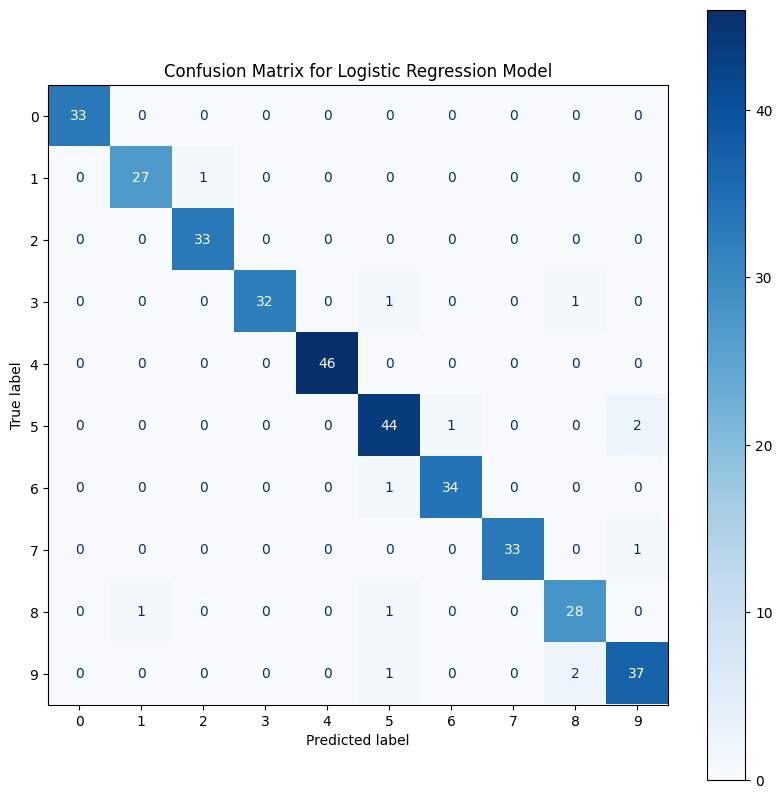

Model performance evaluation complete.


In [4]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

# 2. Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# 3. Print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Generate and display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Logistic Regression Model")
plt.show()

print("Model performance evaluation complete.")

In [5]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['liblinear', 'saga'],       # Solvers that support 'l1' and 'l2'
    'penalty': ['l1', 'l2']              # Regularization type
}

# Instantiate GridSearchCV with the model, parameter grid, and cross-validation settings
# Setting n_jobs=-1 to use all available CPU cores for parallel processing
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Print the best cross-validation score achieved
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-validation Accuracy: 0.9645


Best estimator retrieved from GridSearchCV.
Predictions made on the test set using the tuned model.

Overall Accuracy of Tuned Model: 0.9556

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      0.96      0.95        28
           2       0.97      1.00      0.99        33
           3       1.00      0.94      0.97        34
           4       0.98      0.96      0.97        46
           5       0.94      0.94      0.94        47
           6       0.94      0.97      0.96        35
           7       1.00      0.97      0.99        34
           8       0.88      0.93      0.90        30
           9       0.93      0.93      0.93        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



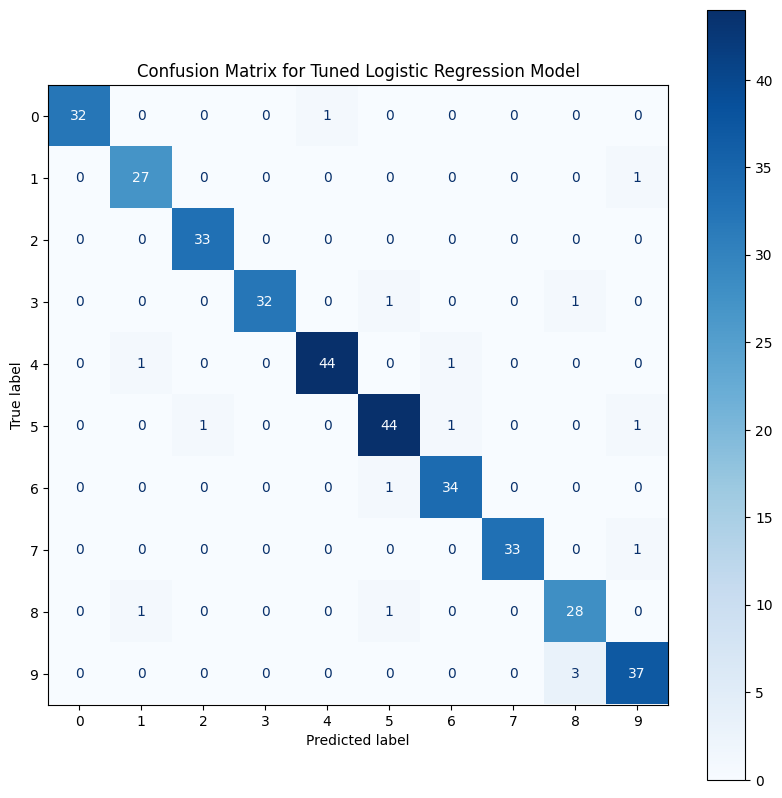

Tuned model performance evaluation complete.


In [6]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Retrieve the best estimator from GridSearchCV
best_model = grid_search.best_estimator_
print("Best estimator retrieved from GridSearchCV.")

# 2. Make predictions on the test set using the best estimator
y_pred_tuned = best_model.predict(X_test)
print("Predictions made on the test set using the tuned model.")

# 3. Calculate and print the overall accuracy of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nOverall Accuracy of Tuned Model: {accuracy_tuned:.4f}")

# 4. Print a classification report for the tuned model
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

# 5. Generate and display the confusion matrix for the tuned model
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Tuned Logistic Regression Model")
plt.show()

print("Tuned model performance evaluation complete.")

Dimensionality of test data reduced to 2D using PCA.
Predictions made for the PCA visualization.


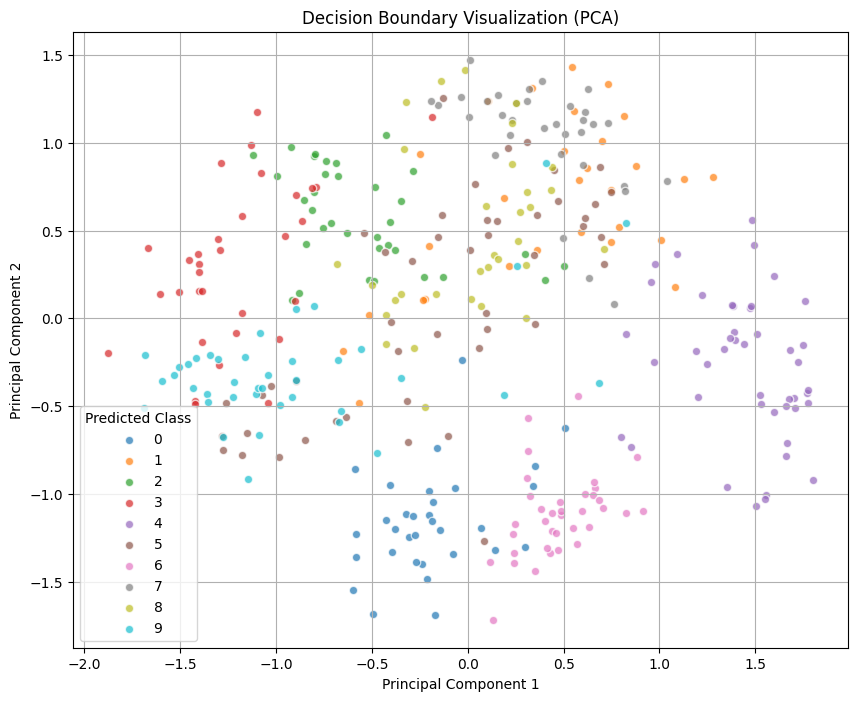

Decision boundary visualization complete.


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Instantiate PCA with n_components=2 and random_state=42
pca = PCA(n_components=2, random_state=42)

# 2. Apply PCA to the scaled test data (X_test) to reduce its dimensionality to 2D
X_test_pca = pca.fit_transform(X_test)
print("Dimensionality of test data reduced to 2D using PCA.")

# 3. Use the best_model to predict the classes (y_pred_pca) for the original X_test data
y_pred_pca = best_model.predict(X_test)
print("Predictions made for the PCA visualization.")

# 4. Create a scatter plot of X_test_pca, coloring the points based on y_pred_pca
plt.figure(figsize=(10, 8))
for i in range(10): # Assuming 10 classes (digits 0-9)
    plt.scatter(
        X_test_pca[y_pred_pca == i, 0],
        X_test_pca[y_pred_pca == i, 1],
        label=str(i),
        alpha=0.7,
        edgecolors='w'
    )

# 5. Add appropriate labels for the x and y axes
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 6. Add a title to the plot
plt.title('Decision Boundary Visualization (PCA)')

# 7. Include a legend to identify the classes in the plot
plt.legend(title='Predicted Class')
plt.grid(True)

# 8. Display the plot
plt.show()

print("Decision boundary visualization complete.")